In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
import numpy as np
import os

In [10]:
img_size = 260
batch_size = 32
num_classes = 17  # Adjust based on your dataset
base_lr = 1e-4
fine_tune_lr = 1e-5

In [11]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    brightness_range=(0.7, 1.3),
    channel_shift_range=20.0,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [12]:
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [13]:
train_generator = train_datagen.flow_from_directory(
    "dataset/archive/PlantVillage/train",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

Found 52019 images belonging to 38 classes.


In [14]:
val_generator = val_datagen.flow_from_directory(
    "dataset/archive/PlantVillage/val",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 10861 images belonging to 38 classes.


In [15]:
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

labels = train_generator.classes  # array of class indices
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights_dict = dict(enumerate(class_weights))

In [18]:
base_model = EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(img_size, img_size, 3)
)
base_model.trainable = False  # Freeze base

2025-07-09 05:03:32.034845: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


24274472/24274472 [==============================] - 4s 0us/step


In [19]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(train_generator.num_classes, activation='softmax')
])

In [20]:
model.compile(optimizer=Adam(learning_rate=base_lr),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [21]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_cb = ModelCheckpoint(
    "checkpoints/full_model.keras",
    save_weights_only=False,   # Save full model including optimizer
    save_freq="epoch",
    verbose=1
)

In [24]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_cb]
)

Epoch 1/10
1626/1626 [==============================] - ETA: 0s - loss: 1.5109 - accuracy: 0.5901
Epoch 1: saving model to checkpoints/full_model.keras
1626/1626 [==============================] - 1768s 1s/step - loss: 1.5109 - accuracy: 0.5901 - val_loss: 0.3856 - val_accuracy: 0.8846
Epoch 2/10
1626/1626 [==============================] - ETA: 0s - loss: 0.5770 - accuracy: 0.8273
Epoch 2: saving model to checkpoints/full_model.keras
1626/1626 [==============================] - 1752s 1s/step - loss: 0.5770 - accuracy: 0.8273 - val_loss: 0.2343 - val_accuracy: 0.9278
Epoch 3/10
1626/1626 [==============================] - ETA: 0s - loss: 0.4308 - accuracy: 0.8681
Epoch 3: saving model to checkpoints/full_model.keras
1626/1626 [==============================] - 1745s 1s/step - loss: 0.4308 - accuracy: 0.8681 - val_loss: 0.2004 - val_accuracy: 0.9379
Epoch 4/10
1626/1626 [==============================] - ETA: 0s - loss: 0.3562 - accuracy: 0.8889
Epoch 4: saving model to checkpoints/full

KeyboardInterrupt: 

In [27]:
import shutil
import os

# Create destination folder if it doesn't exist
os.makedirs("saved_models", exist_ok=True)

# Copy the full model file
shutil.copy("checkpoints/full_model.keras", "saved_models/effiecient.keras")

print("efficient.keras")

efficient.keras


In [12]:
from tensorflow.keras.models import load_model

# Load the full model INCLUDING optimizer
model = load_model("effiecient.keras")

In [13]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [16]:
checkpoint_cb = ModelCheckpoint(
    "checkpoints/full_model.keras",   # Path to save the full model
    save_weights_only=False,          # Save entire model including optimizer state
    save_freq='epoch',                # Save after every epoch
    verbose=1
)

# Resume training from epoch 10 to 15
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=11,              # Train until epoch 15
    initial_epoch=7,
    class_weight=class_weights_dict,# Resume from epoch 10
    callbacks=[checkpoint_cb]
)

Epoch 8/11
1626/1626 [==============================] - ETA: 0s - loss: 0.2434 - accuracy: 0.9227
Epoch 8: saving model to checkpoints/full_model.keras
1626/1626 [==============================] - 1531s 933ms/step - loss: 0.2434 - accuracy: 0.9227 - val_loss: 0.1189 - val_accuracy: 0.9614
Epoch 9/11
1626/1626 [==============================] - ETA: 0s - loss: 0.2295 - accuracy: 0.9263
Epoch 9: saving model to checkpoints/full_model.keras
1626/1626 [==============================] - 1528s 939ms/step - loss: 0.2295 - accuracy: 0.9263 - val_loss: 0.1147 - val_accuracy: 0.9632
Epoch 10/11
1626/1626 [==============================] - ETA: 0s - loss: 0.2201 - accuracy: 0.9290
Epoch 10: saving model to checkpoints/full_model.keras
1626/1626 [==============================] - 1523s 936ms/step - loss: 0.2201 - accuracy: 0.9290 - val_loss: 0.1150 - val_accuracy: 0.9617
Epoch 11/11
1626/1626 [==============================] - ETA: 0s - loss: 0.2047 - accuracy: 0.9340
Epoch 11: saving model to che

340/340 [==============================] - 139s 401ms/step
Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.89      0.92       126
                                 Apple___Black_rot       1.00      0.97      0.98       125
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.94      0.99      0.97       329
                               Blueberry___healthy       0.97      1.00      0.98       300
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       210
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.80      0.85       103
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       2

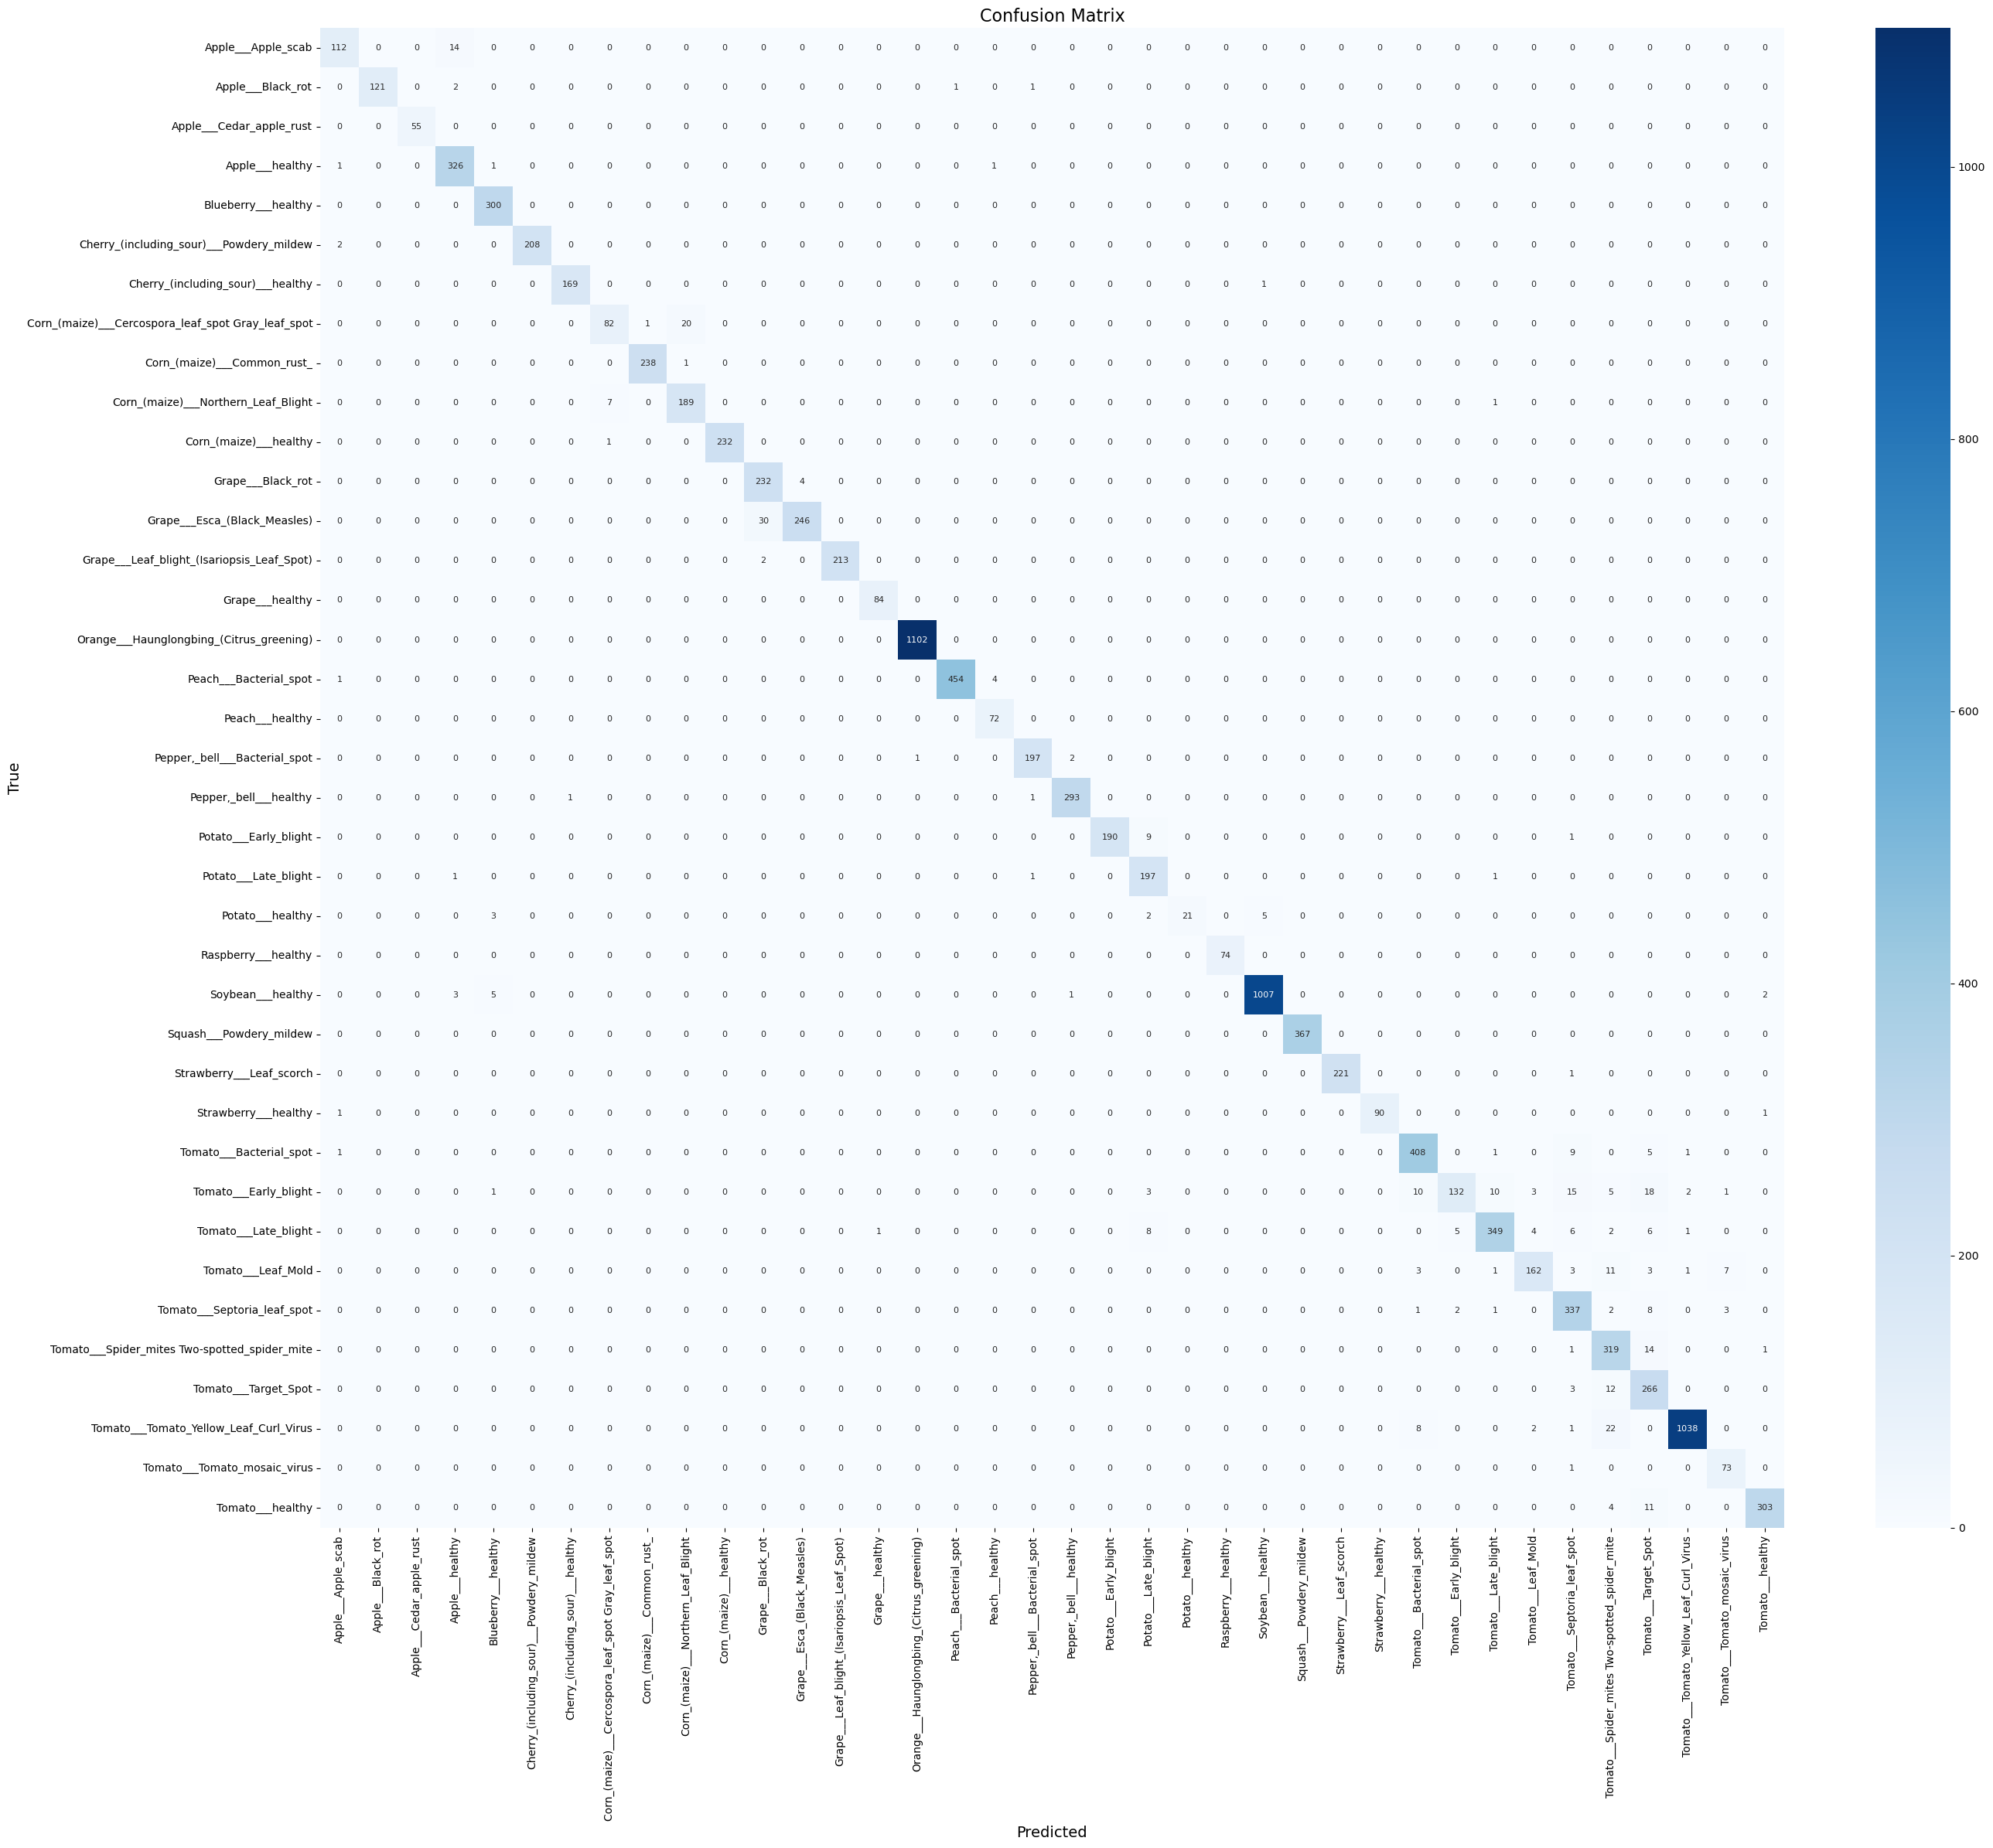

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
val_generator.reset()
pred_probs = model.predict(val_generator)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Classification report
print("Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(28, 24))  # Bigger figure to prevent overlap
sns.heatmap(
    cm,
    annot=True,                # ✅ show values inside cells
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={"size": 8}      # ✅ control number size
)

plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)

plt.xticks(rotation=90, fontsize=10)  # ✅ vertical x labels
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
import shutil
import os

# Create destination folder if it doesn't exist
os.makedirs("saved_models", exist_ok=True)

# Copy the full model file
shutil.copy("checkpoints/full_model.keras", "saved_models/effiecient11.keras")

print("efficient.keras")

efficient.keras


In [13]:
from tensorflow.keras.models import load_model

# Load the full model INCLUDING optimizer
model = load_model("effiecient11.keras")

In [14]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [16]:
checkpoint_cb = ModelCheckpoint(
    "checkpoints/full_model.keras",   # Path to save the full model
    save_weights_only=False,          # Save entire model including optimizer state
    save_freq='epoch',                # Save after every epoch
    verbose=1
)

# Resume training from epoch 10 to 15
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,              # Train until epoch 15
    initial_epoch=11,
    class_weight=class_weights_dict,# Resume from epoch 10
    callbacks=[checkpoint_cb]
)

Epoch 12/20
1626/1626 [==============================] - ETA: 0s - loss: 0.1987 - accuracy: 0.9363
Epoch 12: saving model to checkpoints/full_model.keras
1626/1626 [==============================] - 1530s 941ms/step - loss: 0.1987 - accuracy: 0.9363 - val_loss: 0.1086 - val_accuracy: 0.9642
Epoch 13/20
1626/1626 [==============================] - ETA: 0s - loss: 0.1910 - accuracy: 0.9386
Epoch 13: saving model to checkpoints/full_model.keras
1626/1626 [==============================] - 1557s 957ms/step - loss: 0.1910 - accuracy: 0.9386 - val_loss: 0.0991 - val_accuracy: 0.9666
Epoch 14/20
1626/1626 [==============================] - ETA: 0s - loss: 0.1892 - accuracy: 0.9405
Epoch 14: saving model to checkpoints/full_model.keras
1626/1626 [==============================] - 1554s 955ms/step - loss: 0.1892 - accuracy: 0.9405 - val_loss: 0.0927 - val_accuracy: 0.9704
Epoch 15/20
1626/1626 [==============================] - ETA: 0s - loss: 0.1787 - accuracy: 0.9423
Epoch 15: saving model to

In [ ]:
import shutil
import os

# Create destination folder if it doesn't exist
os.makedirs("saved_models", exist_ok=True)

# Copy the full model file
shutil.copy("checkpoints/full_model.keras", "saved_models/effiecient.keras")

print("efficient.keras")

In [11]:
from tensorflow.keras.models import load_model

# Load the full model INCLUDING optimizer
model = load_model("effiecient20.keras")

In [12]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
checkpoint_cb = ModelCheckpoint(
    "checkpoints/full_model.keras",   # Path to save the full model
    save_weights_only=False,          # Save entire model including optimizer state
    save_freq='epoch',                # Save after every epoch
    verbose=1
)

# Resume training from epoch 10 to 15
history=model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,              # Train until epoch 15
    initial_epoch=20,
    class_weight=class_weights_dict,# Resume from epoch 10
    callbacks=[checkpoint_cb]
)

Epoch 21/30
1626/1626 [==============================] - ETA: 0s - loss: 0.1592 - accuracy: 0.9484
Epoch 21: saving model to checkpoints/full_model.keras
1626/1626 [==============================] - 1780s 1s/step - loss: 0.1592 - accuracy: 0.9484 - val_loss: 0.0815 - val_accuracy: 0.9736
Epoch 22/30
1626/1626 [==============================] - ETA: 0s - loss: 0.1545 - accuracy: 0.9503
Epoch 22: saving model to checkpoints/full_model.keras
1626/1626 [==============================] - 2514s 2s/step - loss: 0.1545 - accuracy: 0.9503 - val_loss: 0.0832 - val_accuracy: 0.9725
Epoch 23/30
1626/1626 [==============================] - ETA: 0s - loss: 0.1501 - accuracy: 0.9514
Epoch 23: saving model to checkpoints/full_model.keras
1626/1626 [==============================] - 2028s 1s/step - loss: 0.1501 - accuracy: 0.9514 - val_loss: 0.0734 - val_accuracy: 0.9764
Epoch 24/30
1626/1626 [==============================] - ETA: 0s - loss: 0.1489 - accuracy: 0.9523
Epoch 24: saving model to checkpoi

In [13]:
from tensorflow.keras.models import load_model

# Replace with your model directory path
model = load_model('effiecient29.keras')

# Summary (optional)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b0 (Functio  (None, 9, 9, 1280)        5919312   
 nal)                                                            
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 512)               655872    
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               1

In [14]:
base_model.trainable = True

In [15]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

# Compile the model again (optional but safe)
model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ Save only the best model based on lowest validation loss
checkpoint_cb = ModelCheckpoint(
    filepath="finetuningcheckpoints/best_model.keras",  # Use .keras or .h5
    save_weights_only=False,      # Save entire model (not just weights)
    monitor='val_loss',
    mode='min',                   # Looking for lowest val_loss
    verbose=1
)

early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Resume training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=35,
    initial_epoch=29,  # resumes from epoch 9
    callbacks=[checkpoint_cb, early_stopping_cb],
    class_weight=class_weights_dict
)


Epoch 30/35
1626/1626 [==============================] - ETA: 0s - loss: 0.1300 - accuracy: 0.9584
Epoch 30: saving model to finetuningcheckpoints/best_model.keras
1626/1626 [==============================] - 1526s 931ms/step - loss: 0.1300 - accuracy: 0.9584 - val_loss: 0.0712 - val_accuracy: 0.9767
Epoch 31/35
1626/1626 [==============================] - ETA: 0s - loss: 0.1244 - accuracy: 0.9596
Epoch 31: saving model to finetuningcheckpoints/best_model.keras
1626/1626 [==============================] - 1527s 939ms/step - loss: 0.1244 - accuracy: 0.9596 - val_loss: 0.0678 - val_accuracy: 0.9780
Epoch 32/35
1626/1626 [==============================] - ETA: 0s - loss: 0.1260 - accuracy: 0.9592
Epoch 32: saving model to finetuningcheckpoints/best_model.keras
1626/1626 [==============================] - 1619s 996ms/step - loss: 0.1260 - accuracy: 0.9592 - val_loss: 0.0675 - val_accuracy: 0.9779
Epoch 33/35
1626/1626 [==============================] - ETA: 0s - loss: 0.1235 - accuracy: 0.

In [16]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=37,
    initial_epoch=35,  # resumes from epoch 9
    callbacks=[checkpoint_cb, early_stopping_cb],
    class_weight=class_weights_dict
)

Epoch 36/37
1626/1626 [==============================] - ETA: 0s - loss: 0.1248 - accuracy: 0.9597
Epoch 36: saving model to finetuningcheckpoints/best_model.keras
1626/1626 [==============================] - 1710s 1s/step - loss: 0.1248 - accuracy: 0.9597 - val_loss: 0.0680 - val_accuracy: 0.9781
Epoch 37/37
1626/1626 [==============================] - ETA: 0s - loss: 0.1218 - accuracy: 0.9613
Epoch 37: saving model to finetuningcheckpoints/best_model.keras
1626/1626 [==============================] - 1710s 1s/step - loss: 0.1218 - accuracy: 0.9613 - val_loss: 0.0691 - val_accuracy: 0.9773


In [20]:
from tensorflow.keras.models import load_model

# Replace with your model directory path
model = load_model('efficient2-37.keras')

In [21]:
base_model.trainable = True

In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

# Compile the model again (optional but safe)
model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ Save only the best model based on lowest validation loss
checkpoint_cb = ModelCheckpoint(
    filepath="finetuningcheckpoints/best_model.h5",  # use .keras or .h5 extension
    save_best_only=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)

early_stopping_cb = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)
# Resume training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=45,
    initial_epoch=37,  # resumes from epoch 9
    callbacks=[checkpoint_cb, early_stopping_cb],
    class_weight=class_weights_dict
)

Epoch 38/45
1626/1626 [==============================] - ETA: 0s - loss: 0.1208 - accuracy: 0.9605
Epoch 38: val_loss improved from inf to 0.06693, saving model to finetuningcheckpoints/best_model.h5


/opt/conda/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1626/1626 [==============================] - 1587s 968ms/step - loss: 0.1208 - accuracy: 0.9605 - val_loss: 0.0669 - val_accuracy: 0.9783
Epoch 39/45
1626/1626 [==============================] - ETA: 0s - loss: 0.1192 - accuracy: 0.9614
Epoch 39: val_loss did not improve from 0.06693
1626/1626 [==============================] - 1559s 958ms/step - loss: 0.1192 - accuracy: 0.9614 - val_loss: 0.0683 - val_accuracy: 0.9776
Epoch 40/45
1626/1626 [==============================] - ETA: 0s - loss: 0.1214 - accuracy: 0.9609
Epoch 40: val_loss did not improve from 0.06693
1626/1626 [==============================] - 1562s 961ms/step - loss: 0.1214 - accuracy: 0.9609 - val_loss: 0.0674 - val_accuracy: 0.9782
Epoch 41/45
1626/1626 [==============================] - ETA: 0s - loss: 0.1172 - accuracy: 0.9615
Epoch 41: val_loss improved from 0.06693 to 0.06670, saving model to finetuningcheckpoints/best_model.h5
1626/1626 [==============================] - 1575s 968ms/step - loss: 0.1172 - accuracy:

KeyboardInterrupt: 

340/340 [==============================] - 171s 493ms/step
Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.92      0.95       126
                                 Apple___Black_rot       1.00      0.96      0.98       125
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.96      0.99      0.97       329
                               Blueberry___healthy       0.98      1.00      0.99       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy       1.00      0.99      1.00       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.83      0.87       103
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       2

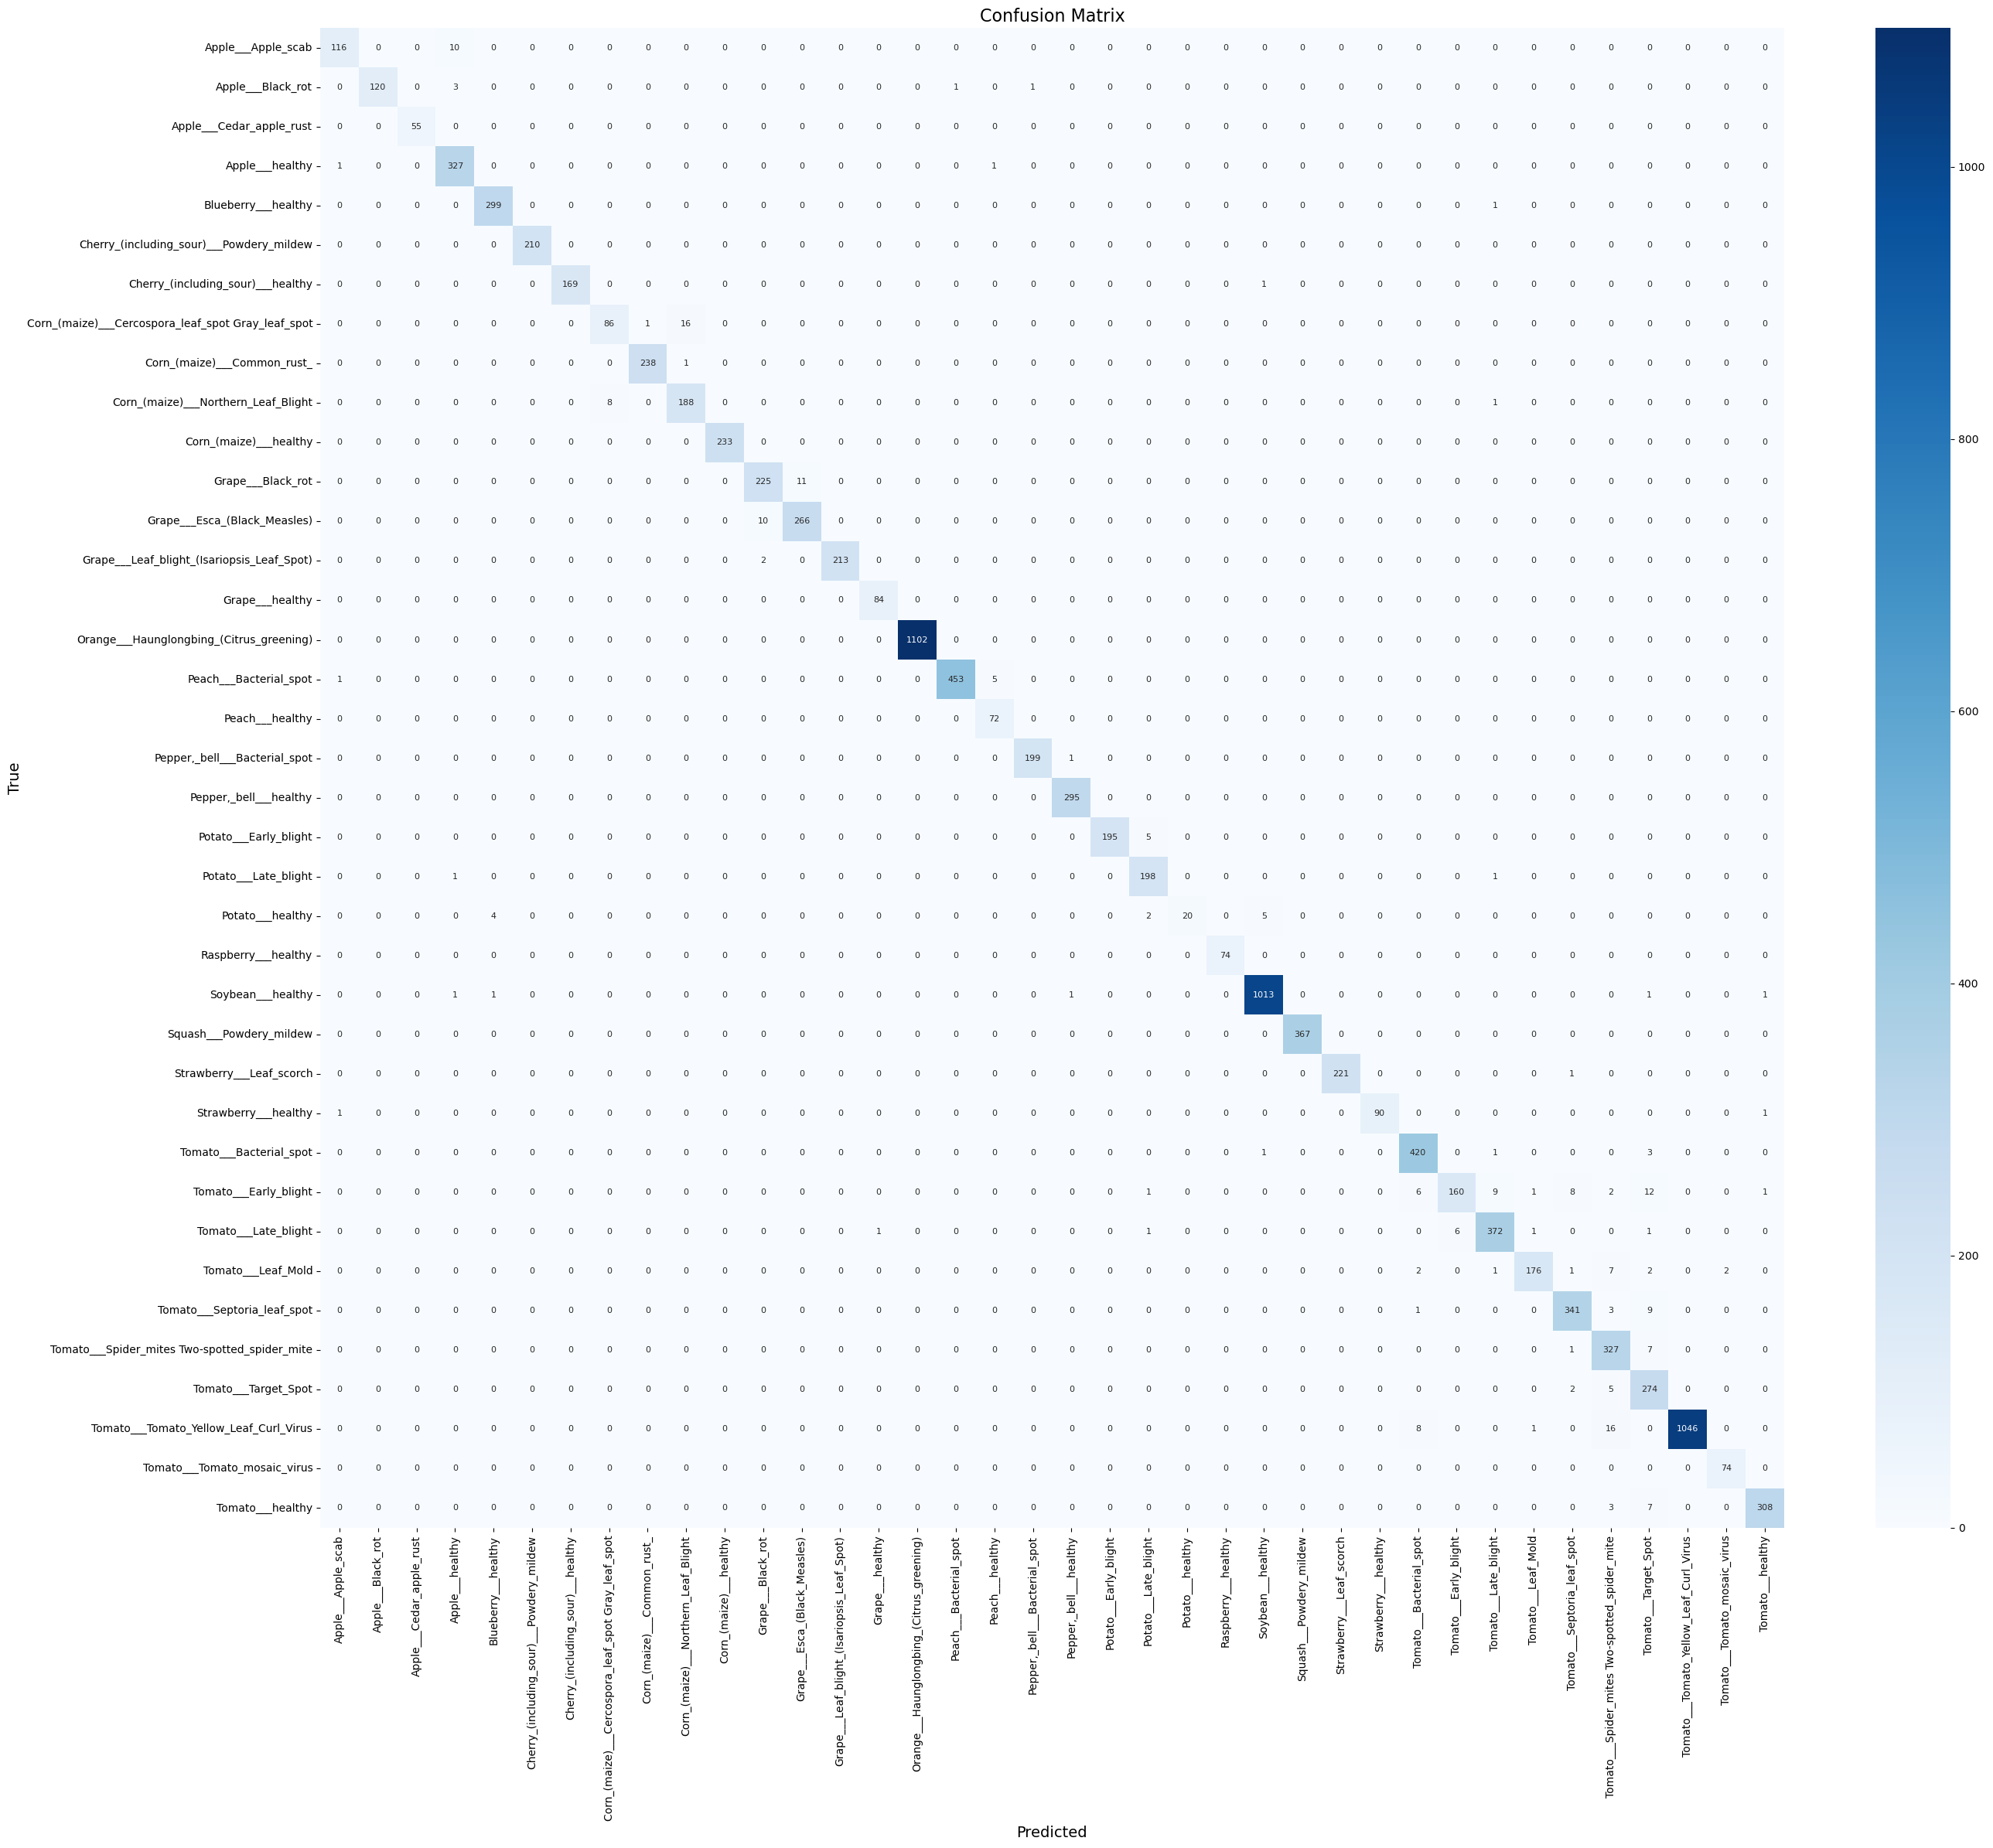

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
val_generator.reset()
pred_probs = model.predict(val_generator)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Classification report
print("Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(28, 24))  # Bigger figure to prevent overlap
sns.heatmap(
    cm,
    annot=True,                # ✅ show values inside cells
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={"size": 8}      # ✅ control number size
)

plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)

plt.xticks(rotation=90, fontsize=10)  # ✅ vertical x labels
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()